# Beat Tracking

In [1]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import librosa.display
import numpy

from mirdotcom import mirdotcom

mirdotcom.init()

## Using `librosa.beat.beat_track`

Load an audio file:

In [2]:
filename = mirdotcom.get_audio(
    "58bpm.wav",
)
x, sr = librosa.load(filename, duration=5)
ipd.Audio(x, rate=sr)

Use [`librosa.beat.beat_track`](https://librosa.org/doc/main/generated/librosa.beat.beat_track.html#librosa.beat.beat_track) to estimate the beat locations and the global tempo:

In [3]:
tempo, beat_times = librosa.beat.beat_track(y=x, sr=sr, start_bpm=60, units="time")
print(tempo)
print(beat_times)

66.25600961538461
[0.06965986 1.06811791]


Plot the beat locations over the waveform:

Text(117.47222222222221, 0.5, 'Amplitude')

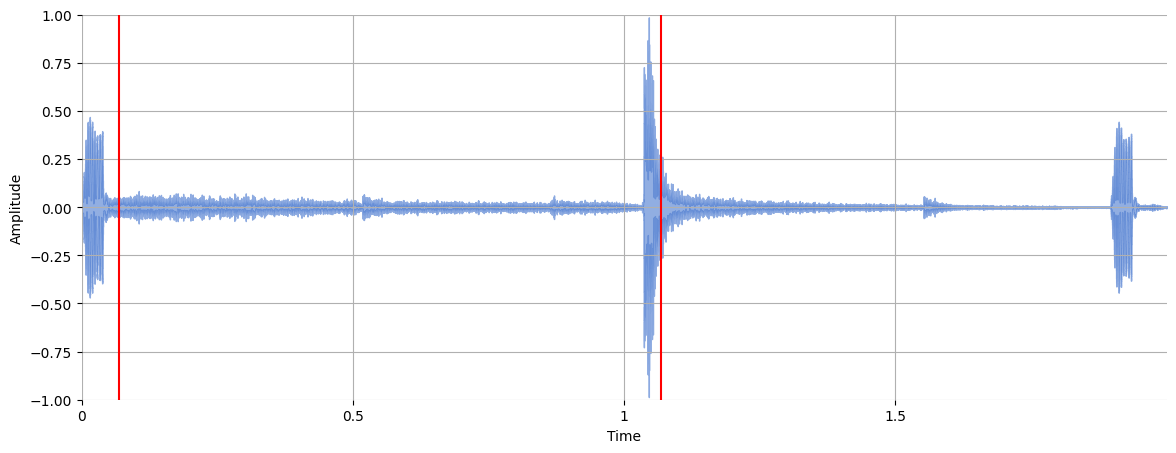

In [4]:
plt.figure(figsize=(14, 5))
librosa.display.waveshow(x, alpha=0.6)
plt.vlines(beat_times, -1, 1, color="r")
plt.ylim(-1, 1)
plt.ylabel("Amplitude")

Plot a histogram of the intervals between adjacent beats:

Text(0, 0.5, 'Count')

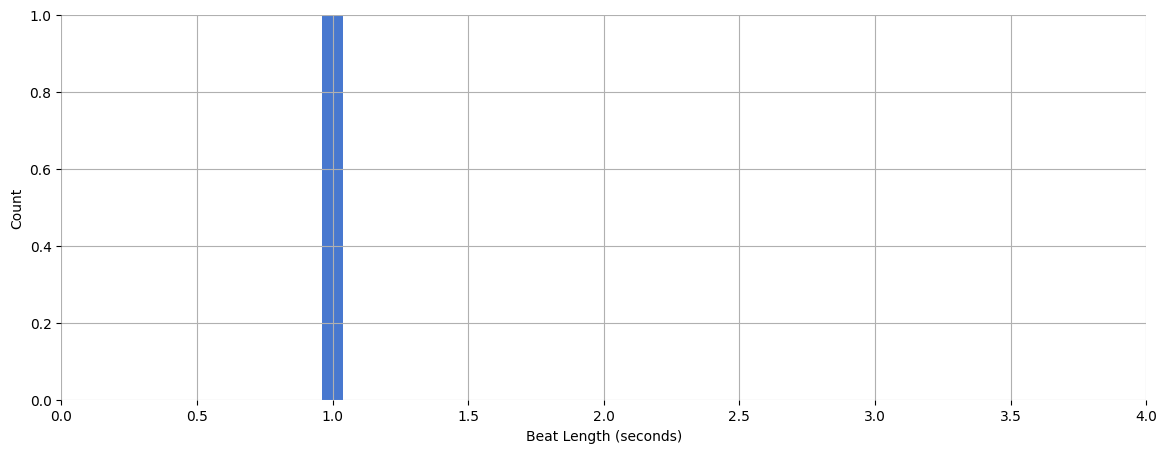

In [5]:
beat_times_diff = numpy.diff(beat_times)
plt.figure(figsize=(14, 5))
plt.hist(beat_times_diff, bins=50, range=(0, 4))
plt.xlabel("Beat Length (seconds)")
plt.ylabel("Count")

Visually, it's difficult to tell how correct the estimated beats are. Let's listen to a click track:

In [6]:
clicks = librosa.clicks(times=beat_times, sr=sr, length=len(x))
ipd.Audio(x + clicks, rate=sr)

## Questions

Try other audio files:

In [7]:
mirdotcom.list_audio()

simple_piano.wav
latin_groove.mp3
clarinet_c6.wav
cowbell.wav
classic_rock_beat.mp3
oboe_c6.wav
sir_duke_trumpet_fast.mp3
sir_duke_trumpet_slow.mp3
jangle_pop.mp3
125_bounce.wav
brahms_hungarian_dance_5.mp3
58bpm.wav
conga_groove.wav
funk_groove.mp3
tone_440.wav
sir_duke_piano_fast.mp3
thx_original.mp3
simple_loop.wav
classic_rock_beat.wav
c_strum.wav
prelude_cmaj.wav
sir_duke_piano_slow.mp3
busta_rhymes_hits_for_days.mp3
